In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    classification_report,
)

# Load data
df = pd.read_csv("../../Data/processed/cleaned_customer_data.csv")
print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded: 50000 rows, 30 columns


In [2]:
features = df.select_dtypes(include=['number']).columns.tolist()

# เอา Churned ออก
features.remove("Churned")

X = df[features]
y = df["Churned"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_importance = pd.Series(rf.feature_importances_, index=features)
rf_importance = rf_importance.sort_values(ascending=False)

print(rf_importance)

Lifetime_Value                   0.128982
Customer_Service_Calls           0.127860
Cart_Abandonment_Rate            0.099109
Discount_Usage_Rate              0.071471
Age                              0.068540
Days_Since_Last_Purchase         0.060889
Total_Purchases                  0.055618
Email_Open_Rate                  0.047294
Average_Order_Value              0.047256
Session_Duration_Avg             0.040777
Pages_Per_Session                0.040606
Returns_Rate                     0.033437
Mobile_App_Usage                 0.033209
Credit_Balance                   0.024860
Social_Media_Engagement_Score    0.024811
Login_Frequency                  0.024470
Wishlist_Items                   0.022099
Membership_Years                 0.021477
Product_Reviews_Written          0.015863
Payment_Method_Diversity         0.009243
Email_Open_Rate_Missing          0.002128
dtype: float64


### ROC-AUC

In [5]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RF ROC-AUC: 0.9212425536697763


0.92 = strong model มาก

### Recall

In [6]:
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7130
           1       0.93      0.77      0.84      2870

    accuracy                           0.92     10000
   macro avg       0.92      0.87      0.89     10000
weighted avg       0.92      0.92      0.92     10000



In [7]:
print("Train AUC:", roc_auc_score(y_train, rf.predict_proba(X_train)[:,1]))
print("Test AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Train AUC: 1.0
Test AUC: 0.9212425536697763


Test AUC = 0.92 (ยัง strong มาก)

แปลว่า model ยัง usable จริง

## Optimize modeling

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [9]:
y_prob = rf.predict_proba(X_test)[:, 1]

In [10]:
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.9047802385757779


In [11]:
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.98      0.91      7130
           1       0.92      0.54      0.68      2870

    accuracy                           0.86     10000
   macro avg       0.88      0.76      0.79     10000
weighted avg       0.87      0.86      0.84     10000



In [12]:
y_pred_final = (y_prob > 0.3).astype(int)

In [13]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.93      0.86      0.90      7130
           1       0.71      0.85      0.78      2870

    accuracy                           0.86     10000
   macro avg       0.82      0.86      0.84     10000
weighted avg       0.87      0.86      0.86     10000



In [14]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

Customer_Service_Calls    0.182533
Cart_Abandonment_Rate     0.162795
Lifetime_Value            0.144901
Total_Purchases           0.101069
Age                       0.061534
Email_Open_Rate           0.054240
Pages_Per_Session         0.049699
Discount_Usage_Rate       0.048110
Average_Order_Value       0.040627
Session_Duration_Avg      0.038028
dtype: float64


## Compare Optimize Model top Old Model

In [15]:
# model เก่า (overfit)
rf_old = RandomForestClassifier(random_state=42)

# model ใหม่ (optimized)
rf_new = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# CV score
cv_old = cross_val_score(rf_old, X, y, cv=5, scoring="roc_auc")
cv_new = cross_val_score(rf_new, X, y, cv=5, scoring="roc_auc")

print("Old model CV AUC:", cv_old.mean())
print("New model CV AUC:", cv_new.mean())

Old model CV AUC: 0.9230513677796758
New model CV AUC: 0.9044811099917753


✅ Model เก่า

- AUC สูงกว่า
- CV ยืนยันแล้ว
- 👉 “เก่งจริง”

🟡 Model ใหม่

- เสถียร
- แต่ performance ลดลง
- 👉 “ปลอดภัย แต่ไม่จำเป็น”

สรุป
เราต้องยึด Insight ก่อน ของ Model ก่อน Customize คือ 

1. Lifetime_Value                   0.128982
2. Customer_Service_Calls           0.127860
3. Cart_Abandonment_Rate            0.099109
4. Discount_Usage_Rate              0.071471
5. Age                              0.068540
6. Days_Since_Last_Purchase         0.060889
7. Total_Purchases                  0.055618
8. Email_Open_Rate                  0.047294
9. Average_Order_Value              0.047256
10. Session_Duration_Avg             0.040777
11. Pages_Per_Session                0.040606
12. Returns_Rate                     0.033437
13. Mobile_App_Usage                 0.033209
14. Credit_Balance                   0.024860
15. Social_Media_Engagement_Score    0.024811
16. Login_Frequency                  0.024470
17. Wishlist_Items                   0.022099
18. Membership_Years                 0.021477
19. Product_Reviews_Written          0.015863
20. Payment_Method_Diversity         0.009243
21. Email_Open_Rate_Missing          0.002128


## ✅ 1. ใช้ Old model

In [16]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_prob = rf.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob)

0.9212425536697763

In [18]:
for t in [0.5, 0.4, 0.3, 0.2]:
    ...

In [19]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

Lifetime_Value              0.128982
Customer_Service_Calls      0.127860
Cart_Abandonment_Rate       0.099109
Discount_Usage_Rate         0.071471
Age                         0.068540
Days_Since_Last_Purchase    0.060889
Total_Purchases             0.055618
Email_Open_Rate             0.047294
Average_Order_Value         0.047256
Session_Duration_Avg        0.040777
dtype: float64

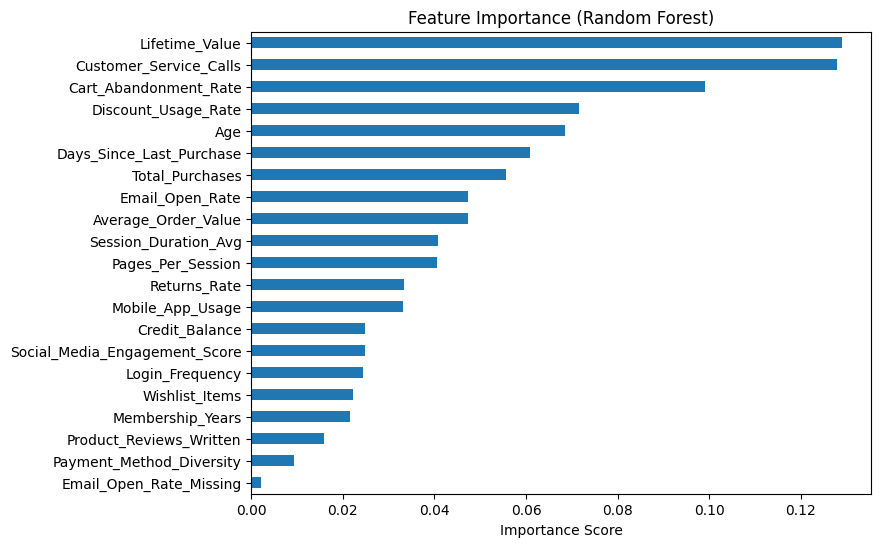

In [20]:
importance = importance.sort_values()

plt.figure(figsize=(8,6))
importance.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

In [27]:
df_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

In [ ]:
importance = importance.sort_values()

q75 = np.percentile(importance, 75)
q50 = np.percentile(importance, 50)
q25 = np.percentile(importance, 25)

def categorize(x):
    if x >= q75:
        return "Strong"
    elif x >= q50:
        return "Moderate"
    elif x >= q25:
        return "Weak"
    else:
        return "None"

df_importance["importance_level"] = df_importance["importance"].apply(categorize)

df_importance.to_csv("../../Data/processed/feature_importance.csv", index=False)
print(df_importance)
